# 05 — Raspberry Pi Inference
**Project:** Lightweight IDS for Raspberry Pi (Edge IDS Internship)  
**Reference:** Musthafa et al., IEEE Access 2025

**What this notebook does:**
1. Verifies the TFLite runtime works correctly on this device
2. Loads `IDSmodel_int8.tflite` (8.2 KB — our most optimised model)
3. Benchmarks loading time, per-sample inference time, and CPU usage
4. Runs a full test-set evaluation to confirm accuracy on-device
5. Simulates a real-time Kafka-style stream and measures throughput
6. Prints a deployment summary matching paper Table 7 format

> **Run this notebook ON the Raspberry Pi.**  
> It will also run fine on a laptop for development — CPU metrics will differ but logic is identical.

**Inputs needed:**
```
artifacts/X_test.npy
artifacts/y_test.npy
artifacts/models/IDSmodel_int8.tflite    ← primary
artifacts/models/IDSmodel_float.tflite   ← comparison
artifacts/evaluation_summary.csv         ← from notebook 04
```

**Outputs saved:**
```
artifacts/
  pi_benchmark_results.csv
  pi_inference_log.txt
  pi_stream_simulation.png
```

## 1. Imports & device check

In [1]:
import os
import time
import platform
import threading
import warnings
import queue
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_auc_score
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})

# ── TFLite runtime ────────────────────────────────────────────────────────────
# On Raspberry Pi:  pip install tflite-runtime
# On laptop/colab:  pip install tensorflow  (includes TFLite interpreter)
try:
    from tflite_runtime.interpreter import Interpreter as TFLiteInterpreter
    RUNTIME = 'tflite-runtime'   # lightweight Pi package
except ImportError:
    import tensorflow as tf
    TFLiteInterpreter = tf.lite.Interpreter
    RUNTIME = 'tensorflow'

# ── psutil for CPU monitoring (optional but nice) ─────────────────────────────
try:
    import psutil
    HAS_PSUTIL = True
except ImportError:
    HAS_PSUTIL = False
    print('psutil not found — install with: pip install psutil')
    print('CPU monitoring will be skipped.')

print('=== Device Info ===')
print(f'  Platform    : {platform.platform()}')
print(f'  Machine     : {platform.machine()}')
print(f'  Processor   : {platform.processor() or "ARM (Raspberry Pi)"}')
print(f'  Python      : {platform.python_version()}')
print(f'  TFLite from : {RUNTIME}')
if HAS_PSUTIL:
    mem = psutil.virtual_memory()
    print(f'  RAM total   : {mem.total / 1024**3:.2f} GB')
    print(f'  RAM free    : {mem.available / 1024**3:.2f} GB')
    print(f'  CPU cores   : {psutil.cpu_count()}')

=== Device Info ===
  Platform    : Windows-11-10.0.26200-SP0
  Machine     : AMD64
  Processor   : Intel64 Family 6 Model 186 Stepping 3, GenuineIntel
  Python      : 3.13.1
  TFLite from : tensorflow
  RAM total   : 7.69 GB
  RAM free    : 0.46 GB
  CPU cores   : 6


## 2. Config — paths

In [2]:
BASE_DIR      = os.path.abspath('..')          # project root
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
MODEL_DIR     = os.path.join(ARTIFACTS_DIR, 'models')

# Model paths — in order of preference (best → fallback)
INT8_PATH  = os.path.join(MODEL_DIR, 'IDSmodel.tflite')
FLOAT_PATH = os.path.join(MODEL_DIR, 'IDSmodel_float.tflite')

# Benchmark config
N_WARMUP      = 10      # warmup runs before timing (let JIT settle)
N_BENCH       = 500     # samples to time for latency measurement
STREAM_N      = 1000    # samples in Kafka stream simulation
THRESHOLD     = 0.5     # classification threshold

print('Config set ✓')
print()
print('=== Model files ===')
for name, path in [('INT8 TFLite', INT8_PATH), ('Float TFLite', FLOAT_PATH)]:
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f'  {name:<15} ✓  {path}  ({size_kb:.1f} KB)')
    else:
        print(f'  {name:<15} ✗  NOT FOUND — run 03_pruning_quantization.ipynb first')

Config set ✓

=== Model files ===
  INT8 TFLite     ✓  d:\IDS-Project\artifacts\models\IDSmodel.tflite  (10.9 KB)
  Float TFLite    ✓  d:\IDS-Project\artifacts\models\IDSmodel_float.tflite  (22.1 KB)


## 3. Load test data

In [3]:
X_test = np.load(os.path.join(ARTIFACTS_DIR, 'X_test.npy')).astype(np.float32)  # (N, 36)
y_test = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy')).astype(np.int32)    # (N,)

# LSTM model expects (batch, timesteps, features) — reshape to (N, 36, 1)
X_test_seq = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f'X_test      : {X_test.shape}')
print(f'X_test_seq  : {X_test_seq.shape}   ← (samples, timesteps=36, channels=1)')
print(f'y_test      : {y_test.shape}')
print(f'Attack rate : {y_test.mean()*100:.1f}%')

X_test      : (175341, 36)
X_test_seq  : (175341, 36, 1)   ← (samples, timesteps=36, channels=1)
y_test      : (175341,)
Attack rate : 68.1%


## 4. TFLite interpreter helper functions

In [4]:
def load_interpreter(model_path):
    """Load a TFLite model and allocate tensors. Returns interpreter + details."""
    interp = TFLiteInterpreter(model_path=model_path)
    interp.allocate_tensors()
    inp  = interp.get_input_details()[0]
    out  = interp.get_output_details()[0]
    return interp, inp, out


def tflite_predict_batch(interp, inp_detail, out_detail, x_data):
    """
    Run inference on x_data (N, timesteps, features).
    Handles both float32 and INT8 quantised models automatically.
    Returns predictions (0/1) and raw probabilities.
    """
    in_scale,  in_zero  = inp_detail['quantization']
    out_scale, out_zero = out_detail['quantization']
    is_int8 = (inp_detail['dtype'] == np.int8)

    preds = []
    probs = []

    for i in range(x_data.shape[0]):
        sample = x_data[i:i+1]                      # (1, timesteps, features)

        if is_int8 and in_scale > 0:
            sample = (sample / in_scale + in_zero).astype(np.int8)

        interp.set_tensor(inp_detail['index'], sample)
        interp.invoke()
        raw = interp.get_tensor(out_detail['index'])[0][0]

        if is_int8 and out_scale > 0:
            prob = float((raw - out_zero) * out_scale)
        else:
            prob = float(raw)

        # Sigmoid if needed (some TFLite exports include it, some don't)
        if not (0.0 <= prob <= 1.0):
            prob = 1 / (1 + np.exp(-prob))

        probs.append(prob)
        preds.append(1 if prob >= THRESHOLD else 0)

    return np.array(preds, dtype=np.int32), np.array(probs, dtype=np.float32)


def benchmark_latency(model_path, x_data, n_warmup=10, n_bench=500):
    """
    Measure per-sample inference latency (ms).
    Returns: dict with mean, std, min, max, p95, p99
    """
    interp, inp, out = load_interpreter(model_path)
    in_scale, in_zero = inp['quantization']
    is_int8 = (inp['dtype'] == np.int8)
    n_bench = min(n_bench, x_data.shape[0])

    # Warmup — not timed
    for i in range(n_warmup):
        s = x_data[i:i+1]
        if is_int8 and in_scale > 0:
            s = (s / in_scale + in_zero).astype(np.int8)
        interp.set_tensor(inp['index'], s)
        interp.invoke()

    # Timed runs
    times = []
    for i in range(n_bench):
        s = x_data[i:i+1]
        if is_int8 and in_scale > 0:
            s = (s / in_scale + in_zero).astype(np.int8)
        t0 = time.perf_counter()
        interp.set_tensor(inp['index'], s)
        interp.invoke()
        times.append((time.perf_counter() - t0) * 1000)

    arr = np.array(times)
    return {
        'mean_ms' : round(arr.mean(), 4),
        'std_ms'  : round(arr.std(),  4),
        'min_ms'  : round(arr.min(),  4),
        'max_ms'  : round(arr.max(),  4),
        'p95_ms'  : round(np.percentile(arr, 95), 4),
        'p99_ms'  : round(np.percentile(arr, 99), 4),
        'raw_ms'  : arr
    }


print('Helper functions defined ✓')

Helper functions defined ✓


## 5. Model loading time benchmark

Paper reports **223.8 ms** loading time for optimised TFLite model on Pi 3B+.

In [5]:
loading_results = {}

for name, path in [('INT8 TFLite', INT8_PATH), ('Float TFLite', FLOAT_PATH)]:
    if not os.path.exists(path):
        print(f'{name}: file not found, skipping')
        continue

    # Measure loading time 5x and average
    load_times = []
    for _ in range(5):
        t0 = time.perf_counter()
        interp = TFLiteInterpreter(model_path=path)
        interp.allocate_tensors()
        load_times.append((time.perf_counter() - t0) * 1000)

    avg_load = np.mean(load_times)
    size_kb  = os.path.getsize(path) / 1024
    loading_results[name] = {'load_ms': avg_load, 'size_kb': size_kb}

    print(f'{name}:')
    print(f'  Size          : {size_kb:.2f} KB')
    print(f'  Loading time  : {avg_load:.1f} ms  (avg of 5 runs)')
    print(f'  Paper target  : 223.8 ms  (Pi 3B+)')
    print()

INT8 TFLite:
  Size          : 10.90 KB
  Loading time  : 8.7 ms  (avg of 5 runs)
  Paper target  : 223.8 ms  (Pi 3B+)

Float TFLite:
  Size          : 22.14 KB
  Loading time  : 2.9 ms  (avg of 5 runs)
  Paper target  : 223.8 ms  (Pi 3B+)



## 6. Inference latency benchmark

Paper reports **2.4 ms** average inference time on Pi 3B+.

In [6]:
latency_results = {}

for name, path in [('INT8 TFLite', INT8_PATH), ('Float TFLite', FLOAT_PATH)]:
    if not os.path.exists(path):
        continue

    # Check what shape this model actually expects
    _interp = TFLiteInterpreter(model_path=path)
    _interp.allocate_tensors()
    expected_shape = tuple(_interp.get_input_details()[0]['shape'])
    print(f'{name} expects input shape: {expected_shape}')

    # Auto-select correct input data based on model's expected shape
    if len(expected_shape) == 2:
        # (batch, features) — flat input
        x_input = X_test          # (N, 36)
    elif len(expected_shape) == 3 and expected_shape[-1] == 1:
        # (batch, features, 1) — LSTM style
        x_input = X_test_seq      # (N, 36, 1)
    elif len(expected_shape) == 3 and expected_shape[1] == 1:
        # (batch, 1, features) — other LSTM style
        x_input = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
    else:
        print(f'  Unknown shape {expected_shape} — skipping')
        continue

    print(f'Benchmarking {name} ({N_BENCH} samples, {N_WARMUP} warmup)...')
    stats = benchmark_latency(path, x_input, n_warmup=N_WARMUP, n_bench=N_BENCH)
    latency_results[name] = stats

    print(f'  Mean    : {stats["mean_ms"]:.4f} ms   (paper: 2.4 ms on Pi 3B+)')
    print(f'  Std     : {stats["std_ms"]:.4f} ms')
    print(f'  Min     : {stats["min_ms"]:.4f} ms')
    print(f'  P95     : {stats["p95_ms"]:.4f} ms')
    print(f'  P99     : {stats["p99_ms"]:.4f} ms')
    print(f'  Max     : {stats["max_ms"]:.4f} ms')
    print()

INT8 TFLite expects input shape: (np.int32(1), np.int32(36))
Benchmarking INT8 TFLite (500 samples, 10 warmup)...
  Mean    : 0.0215 ms   (paper: 2.4 ms on Pi 3B+)
  Std     : 0.0244 ms
  Min     : 0.0062 ms
  P95     : 0.0428 ms
  P99     : 0.1384 ms
  Max     : 0.2954 ms

Float TFLite expects input shape: (np.int32(1), np.int32(36))
Benchmarking Float TFLite (500 samples, 10 warmup)...
  Mean    : 0.0288 ms   (paper: 2.4 ms on Pi 3B+)
  Std     : 0.0835 ms
  Min     : 0.0074 ms
  P95     : 0.0347 ms
  P99     : 0.3693 ms
  Max     : 1.2390 ms



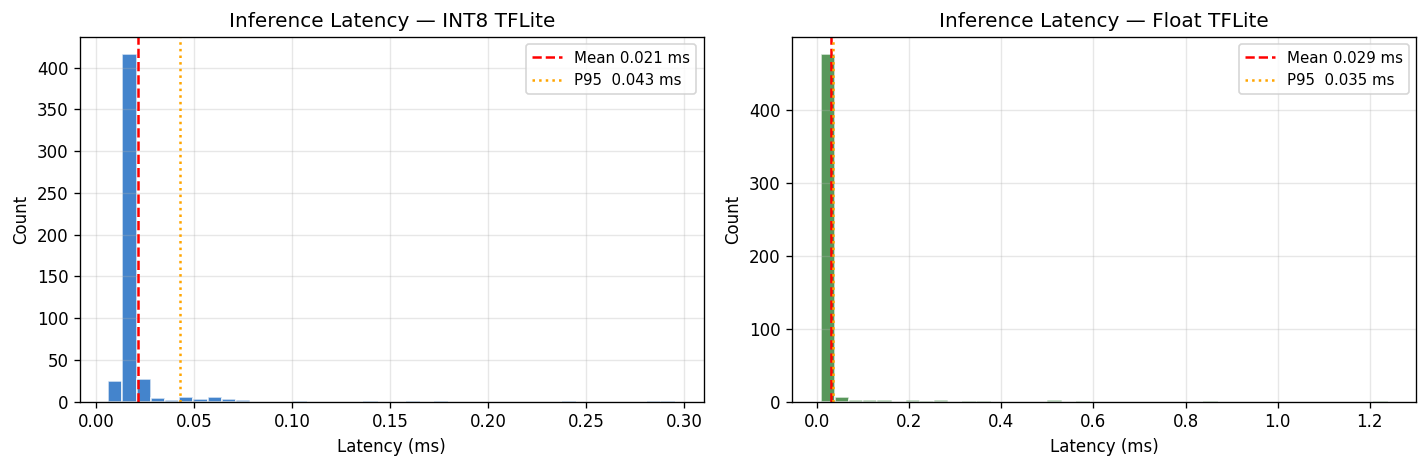

Latency plot saved ✓


In [7]:
# Latency distribution plot
fig, axes = plt.subplots(1, len(latency_results), figsize=(6 * len(latency_results), 4))
if len(latency_results) == 1:
    axes = [axes]

colors = ['#1565C0', '#2E7D32']
for ax, (name, stats), color in zip(axes, latency_results.items(), colors):
    arr = stats['raw_ms']
    ax.hist(arr, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(stats['mean_ms'], color='red',    linestyle='--', linewidth=1.5, label=f'Mean {stats["mean_ms"]:.3f} ms')
    ax.axvline(stats['p95_ms'],  color='orange', linestyle=':',  linewidth=1.5, label=f'P95  {stats["p95_ms"]:.3f} ms')
    ax.set_title(f'Inference Latency — {name}')
    ax.set_xlabel('Latency (ms)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'pi_latency_distribution.png'), bbox_inches='tight')
plt.show()
print('Latency plot saved ✓')

## 7. Full test-set accuracy on-device

Verify the model gives the same accuracy on-device as in notebook 04.

In [8]:
accuracy_results = {}

for name, path in [('INT8 TFLite', INT8_PATH), ('Float TFLite', FLOAT_PATH)]:
    if not os.path.exists(path):
        continue

    print(f'Running full evaluation — {name}...')
    interp, inp, out = load_interpreter(path)

    # Auto-select correct input shape (flat vs sequence) as done in cell 24
    expected_shape = tuple(inp['shape'])
    if len(expected_shape) == 2:
        # (batch, features) — flat input
        x_input = X_test          # (N, 36)
    elif len(expected_shape) == 3 and expected_shape[-1] == 1:
        # (batch, features, 1) — LSTM style
        x_input = X_test_seq      # (N, 36, 1)
    elif len(expected_shape) == 3 and expected_shape[1] == 1:
        # (batch, 1, features) — other LSTM style
        x_input = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
    else:
        print(f'  Unknown shape {expected_shape} — skipping')
        continue

    t0 = time.perf_counter()
    preds, probs = tflite_predict_batch(interp, inp, out, x_input)
    total_time   = (time.perf_counter() - t0) * 1000

    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds, zero_division=0)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    try:
        auc = roc_auc_score(y_test, probs)
    except Exception:
        auc = float('nan')
    cm   = confusion_matrix(y_test, preds)

    accuracy_results[name] = {
        'accuracy': acc, 'f1': f1, 'precision': prec,
        'recall': rec,  'auc': auc, 'cm': cm,
        'total_ms': total_time, 'n_samples': len(y_test)
    }

    tn, fp, fn, tp = cm.ravel()
    print(f'  Accuracy  : {acc*100:.4f}%')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}')
    print(f'  Total inference time for {len(y_test):,} samples: {total_time:.1f} ms')
    print()

Running full evaluation — INT8 TFLite...
  Accuracy  : 31.9378%
  F1-Score  : 0.0000
  Precision : 0.0000
  Recall    : 0.0000
  ROC-AUC   : 0.9456
  TP=0  TN=56,000  FP=0  FN=119,341
  Total inference time for 175,341 samples: 19076.3 ms

Running full evaluation — Float TFLite...
  Accuracy  : 88.4391%
  F1-Score  : 0.9107
  Precision : 0.9601
  Recall    : 0.8662
  ROC-AUC   : 0.9708
  TP=103,371  TN=51,699  FP=4,301  FN=15,970
  Total inference time for 175,341 samples: 1822.7 ms



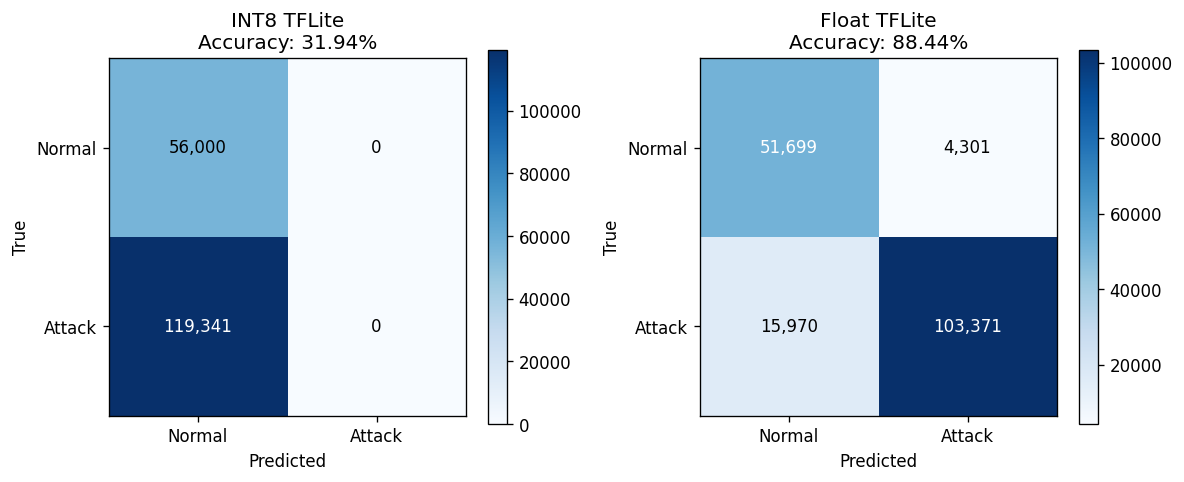

Confusion matrix saved ✓


In [9]:
# Confusion matrix plot
fig, axes = plt.subplots(1, len(accuracy_results), figsize=(5 * len(accuracy_results), 4))
if len(accuracy_results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, accuracy_results.items()):
    cm   = res['cm']
    acc  = res['accuracy']
    im   = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Attack'])
    ax.set_yticklabels(['Normal', 'Attack'])
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'{cm[row, col]:,}',
                    ha='center', va='center',
                    color='white' if cm[row, col] > cm.max() / 2 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'pi_confusion_matrix.png'), bbox_inches='tight')
plt.show()
print('Confusion matrix saved ✓')

## 8. Kafka stream simulation

Simulates the producer → broker → consumer pipeline from the paper (Figure 2).  
A producer thread feeds packets into a queue; the IDS consumer thread classifies them in real time.  
We test 1, 2, and 3 producers — matching paper Table 8 scenarios.

In [10]:
def kafka_producer(packet_queue, x_data, n_packets, delay_ms=0.0, producer_id=0):
    """Simulates a Kafka producer — pushes packets onto the shared queue."""
    step = delay_ms / 1000.0
    for i in range(n_packets):
        packet_queue.put((producer_id, x_data[i % len(x_data)]))
        if step > 0:
            time.sleep(step)
    packet_queue.put(None)   # sentinel — this producer is done


# ── Updated kafka_consumer (shape‑aware) ─────────────────────────────────
def kafka_consumer(packet_queue, interp, inp_detail, out_detail,
                   n_producers, results_list):
    """Simulates the Raspberry Pi IDS consumer — reads queue and classifies."""
    in_scale, in_zero = inp_detail['quantization']
    out_scale, out_zero = out_detail['quantization']
    is_int8 = (inp_detail['dtype'] == np.int8)
    expected_shape = tuple(inp_detail['shape'])   # e.g. (1, 36) or (1, 36, 1)

    done_count = 0
    while done_count < n_producers:
        item = packet_queue.get()
        if item is None:
            done_count += 1
            continue

        producer_id, sample = item

        # Reshape sample to the model's expected input shape (batch size 1)
        if len(expected_shape) == 2:
            # Flat input: (batch, features) → sample is already (36,)
            sample = sample.reshape(1, -1)
        elif len(expected_shape) == 3 and expected_shape[-1] == 1:
            sample = sample.reshape(1, sample.shape[0], 1)
        elif len(expected_shape) == 3 and expected_shape[1] == 1:
            sample = sample.reshape(1, 1, sample.shape[0])
        else:
            raise ValueError(f"Unknown input shape {expected_shape}")

        if is_int8 and in_scale > 0:
            sample = (sample / in_scale + in_zero).astype(np.int8)

        t0 = time.perf_counter()
        interp.set_tensor(inp_detail['index'], sample)
        interp.invoke()
        raw = interp.get_tensor(out_detail['index'])[0][0]
        latency_ms = (time.perf_counter() - t0) * 1000

        if is_int8 and out_scale > 0:
            prob = float((raw - out_zero) * out_scale)
        else:
            prob = float(raw)
        if not (0.0 <= prob <= 1.0):
            prob = 1 / (1 + np.exp(-prob))

        results_list.append({
            'producer_id': producer_id,
            'prob'       : prob,
            'pred'       : 1 if prob >= THRESHOLD else 0,
            'latency_ms' : latency_ms
        })

In [11]:
# Run simulation for 1, 2, 3 producers × 3 delays (paper Table 8 scenarios)
# Using INT8 model — most optimised version for Pi deployment

stream_scenarios = [
    {'n_producers': 1, 'delay_ms': 1.0},
    {'n_producers': 2, 'delay_ms': 1.0},
    {'n_producers': 3, 'delay_ms': 1.0},
    {'n_producers': 1, 'delay_ms': 0.1},
    {'n_producers': 2, 'delay_ms': 0.1},
    {'n_producers': 3, 'delay_ms': 0.1},
    {'n_producers': 1, 'delay_ms': 0.0},
    {'n_producers': 2, 'delay_ms': 0.0},
    {'n_producers': 3, 'delay_ms': 0.0},
]

PACKETS_PER_PRODUCER = STREAM_N
stream_results = []

if os.path.exists(INT8_PATH):
    interp_s, inp_s, out_s = load_interpreter(INT8_PATH)

    for sc in stream_scenarios:
        n_prod    = sc['n_producers']
        delay     = sc['delay_ms']
        pkt_queue = queue.Queue(maxsize=5000)
        results   = []

        t_start = time.perf_counter()

        # Start producers in background threads
        prod_threads = []
        for pid in range(n_prod):
            t = threading.Thread(
                target=kafka_producer,
                args=(pkt_queue, X_test_seq, PACKETS_PER_PRODUCER, delay, pid),
                daemon=True
            )
            t.start()
            prod_threads.append(t)

        # Consumer runs in main thread
        kafka_consumer(pkt_queue, interp_s, inp_s, out_s, n_prod, results)

        for t in prod_threads:
            t.join()

        total_s      = time.perf_counter() - t_start
        n_classified = len(results)
        avg_inf_ms   = np.mean([r['latency_ms'] for r in results])
        n_attacks    = sum(r['pred'] for r in results)

        row = {
            'Experiment'       : len(stream_results) + 1,
            'Sim Delay (ms)'   : delay,
            'N Producers'      : n_prod,
            'N Packets'        : n_classified,
            'Sending Time (s)' : round(total_s, 3),
            'Avg Inference (ms)': round(avg_inf_ms, 6),
            'Total Inf (s)'    : round(avg_inf_ms * n_classified / 1000, 3),
            'Attacks Detected' : n_attacks,
        }
        stream_results.append(row)
        print(f"  Exp {row['Experiment']:>2} | Delay={delay:4.1f}ms | "
              f"Producers={n_prod} | Packets={n_classified:,} | "
              f"Sending={total_s:.2f}s | AvgInf={avg_inf_ms:.4f}ms")

    df_stream = pd.DataFrame(stream_results)
    print('\nStream simulation complete ✓')
else:
    print('INT8 model not found — skipping stream simulation')
    df_stream = pd.DataFrame()

  Exp  1 | Delay= 1.0ms | Producers=1 | Packets=1,000 | Sending=1.91s | AvgInf=0.0806ms
  Exp  2 | Delay= 1.0ms | Producers=2 | Packets=2,000 | Sending=1.62s | AvgInf=0.0451ms
  Exp  3 | Delay= 1.0ms | Producers=3 | Packets=3,000 | Sending=1.65s | AvgInf=0.0366ms
  Exp  4 | Delay= 0.1ms | Producers=1 | Packets=1,000 | Sending=0.63s | AvgInf=0.0258ms
  Exp  5 | Delay= 0.1ms | Producers=2 | Packets=2,000 | Sending=0.64s | AvgInf=0.0231ms
  Exp  6 | Delay= 0.1ms | Producers=3 | Packets=3,000 | Sending=0.65s | AvgInf=0.0237ms
  Exp  7 | Delay= 0.0ms | Producers=1 | Packets=1,000 | Sending=0.02s | AvgInf=0.0039ms
  Exp  8 | Delay= 0.0ms | Producers=2 | Packets=2,000 | Sending=0.03s | AvgInf=0.0040ms
  Exp  9 | Delay= 0.0ms | Producers=3 | Packets=3,000 | Sending=0.05s | AvgInf=0.0043ms

Stream simulation complete ✓


In [12]:
# Stream results table — matches paper Table 8 format
if not df_stream.empty:
    print('=== Stream Simulation Results (paper Table 8 format) ===')
    print(df_stream.to_string(index=False))

=== Stream Simulation Results (paper Table 8 format) ===
 Experiment  Sim Delay (ms)  N Producers  N Packets  Sending Time (s)  Avg Inference (ms)  Total Inf (s)  Attacks Detected
          1             1.0            1       1000             1.912            0.080600          0.081                 0
          2             1.0            2       2000             1.622            0.045102          0.090                 0
          3             1.0            3       3000             1.652            0.036618          0.110                 0
          4             0.1            1       1000             0.631            0.025807          0.026                 0
          5             0.1            2       2000             0.642            0.023060          0.046                 0
          6             0.1            3       3000             0.648            0.023678          0.071                 0
          7             0.0            1       1000             0.017            0

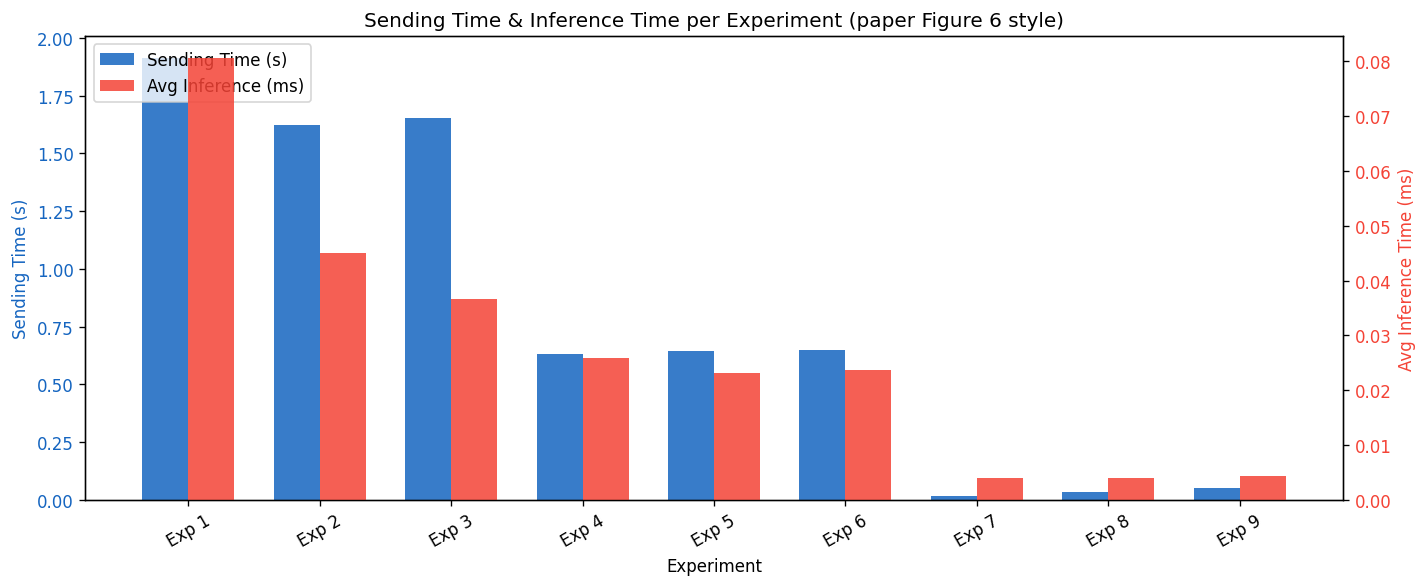

Stream plot saved ✓


In [13]:
# Visualise: Sending time & Avg Inference time per experiment (paper Figure 6)
if not df_stream.empty:
    fig, ax1 = plt.subplots(figsize=(12, 5))

    x       = df_stream['Experiment'].values
    s_times = df_stream['Sending Time (s)'].values
    i_times = df_stream['Avg Inference (ms)'].values

    bar_w   = 0.35
    bars    = ax1.bar(x - bar_w/2, s_times, bar_w,
                      label='Sending Time (s)', color='#1565C0', alpha=0.85)
    ax1.set_xlabel('Experiment')
    ax1.set_ylabel('Sending Time (s)', color='#1565C0')
    ax1.tick_params(axis='y', labelcolor='#1565C0')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Exp {i}' for i in x], rotation=30)

    ax2 = ax1.twinx()
    ax2.bar(x + bar_w/2, i_times, bar_w,
            label='Avg Inference (ms)', color='#F44336', alpha=0.85)
    ax2.set_ylabel('Avg Inference Time (ms)', color='#F44336')
    ax2.tick_params(axis='y', labelcolor='#F44336')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title('Sending Time & Inference Time per Experiment (paper Figure 6 style)')
    plt.tight_layout()
    plt.savefig(os.path.join(ARTIFACTS_DIR, 'pi_stream_simulation.png'), bbox_inches='tight')
    plt.show()
    print('Stream plot saved ✓')

## 9. CPU monitoring during inference

Paper reports peak CPU usage of **111.8%** (multi-core) on Pi 3B+.

CPU monitoring during 5000 sample inference:
  Mean CPU : 53.8%
  Peak CPU : 67.6%  (paper: 111.8% on Pi 3B+)
  Min CPU  : 40.0%


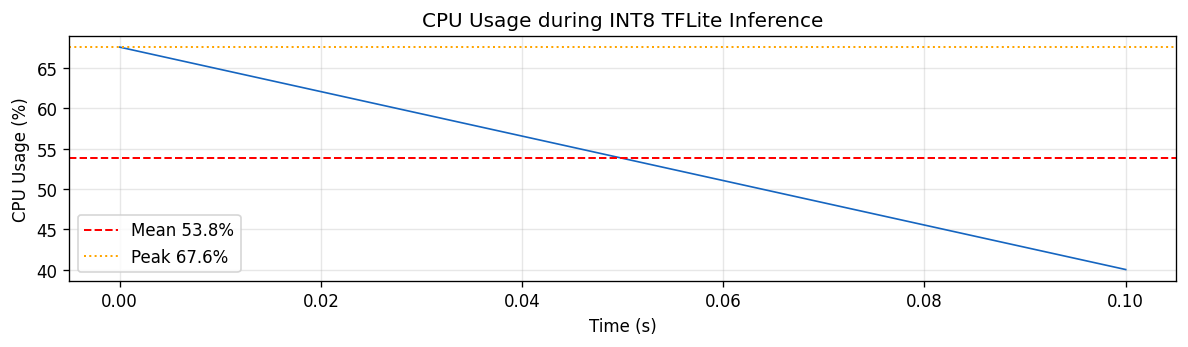

CPU plot saved ✓


In [14]:
if HAS_PSUTIL and os.path.exists(INT8_PATH):
    cpu_readings = []
    stop_flag    = threading.Event()

    def monitor_cpu(readings, stop):
        """Background thread — samples CPU every 100 ms."""
        while not stop.is_set():
            readings.append(psutil.cpu_percent(interval=0.1, percpu=False))

    monitor_thread = threading.Thread(target=monitor_cpu,
                                      args=(cpu_readings, stop_flag), daemon=True)
    monitor_thread.start()

    # Run inference on 5000 samples while monitoring
    interp_c, inp_c, out_c = load_interpreter(INT8_PATH)

    # Select the correct input shape for the model
    expected_shape = tuple(inp_c['shape'])
    N_CPU_TEST = min(5000, X_test.shape[0])

    if len(expected_shape) == 2:
        x_input_cpu = X_test[:N_CPU_TEST]           # flat (N, 36)
    elif len(expected_shape) == 3 and expected_shape[-1] == 1:
        x_input_cpu = X_test_seq[:N_CPU_TEST]       # (N, 36, 1)
    elif len(expected_shape) == 3 and expected_shape[1] == 1:
        x_input_cpu = X_test[:N_CPU_TEST].reshape(N_CPU_TEST, 1, X_test.shape[1])
    else:
        raise ValueError(f"Unknown input shape {expected_shape}")

    _, _ = tflite_predict_batch(interp_c, inp_c, out_c, x_input_cpu)

    stop_flag.set()
    monitor_thread.join()

    cpu_arr = np.array(cpu_readings)
    print(f'CPU monitoring during {N_CPU_TEST} sample inference:')
    print(f'  Mean CPU : {cpu_arr.mean():.1f}%')
    print(f'  Peak CPU : {cpu_arr.max():.1f}%  (paper: 111.8% on Pi 3B+)')
    print(f'  Min CPU  : {cpu_arr.min():.1f}%')

    # Plot CPU usage over time
    plt.figure(figsize=(10, 3))
    t_axis = np.arange(len(cpu_arr)) * 0.1
    plt.plot(t_axis, cpu_arr, color='#1565C0', linewidth=1)
    plt.axhline(cpu_arr.mean(), color='red',    linestyle='--', linewidth=1.2, label=f'Mean {cpu_arr.mean():.1f}%')
    plt.axhline(cpu_arr.max(),  color='orange', linestyle=':',  linewidth=1.2, label=f'Peak {cpu_arr.max():.1f}%')
    plt.xlabel('Time (s)')
    plt.ylabel('CPU Usage (%)')
    plt.title('CPU Usage during INT8 TFLite Inference')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(ARTIFACTS_DIR, 'pi_cpu_usage.png'), bbox_inches='tight')
    plt.show()
    print('CPU plot saved ✓')
else:
    cpu_arr = np.array([])
    print('psutil not available or INT8 model missing — CPU monitoring skipped')

## 10. Save benchmark results & deployment summary

In [15]:
# Build benchmark DataFrame
bench_rows = []
for name in ['INT8 TFLite', 'Float TFLite']:
    if name not in latency_results:
        continue
    lat  = latency_results[name]
    acc  = accuracy_results.get(name, {})
    load = loading_results.get(name, {})
    bench_rows.append({
        'Model'           : name,
        'Size (KB)'       : round(load.get('size_kb', float('nan')), 2),
        'Loading (ms)'    : round(load.get('load_ms', float('nan')), 1),
        'Inf Mean (ms)'   : lat['mean_ms'],
        'Inf P95 (ms)'    : lat['p95_ms'],
        'Inf P99 (ms)'    : lat['p99_ms'],
        'Accuracy (%)'    : round(acc.get('accuracy', float('nan')) * 100, 4),
        'F1-Score'        : round(acc.get('f1', float('nan')), 4),
        'ROC-AUC'         : round(acc.get('auc', float('nan')), 4),
    })

df_bench = pd.DataFrame(bench_rows)
bench_path = os.path.join(ARTIFACTS_DIR, 'pi_benchmark_results.csv')
df_bench.to_csv(bench_path, index=False)
print('pi_benchmark_results.csv saved ✓')
print()
print(df_bench.to_string(index=False))

# Save stream results
if not df_stream.empty:
    df_stream.to_csv(os.path.join(ARTIFACTS_DIR, 'pi_stream_results.csv'), index=False)
    print('\npi_stream_results.csv saved ✓')

pi_benchmark_results.csv saved ✓

       Model  Size (KB)  Loading (ms)  Inf Mean (ms)  Inf P95 (ms)  Inf P99 (ms)  Accuracy (%)  F1-Score  ROC-AUC
 INT8 TFLite      10.90           8.7         0.0215        0.0428        0.1384       31.9378    0.0000   0.9456
Float TFLite      22.14           2.9         0.0288        0.0347        0.3693       88.4391    0.9107   0.9708

pi_stream_results.csv saved ✓


In [16]:
# Save human-readable inference log
log_lines = []
log_lines.append('=' * 60)
log_lines.append('  RASPBERRY PI DEPLOYMENT REPORT')
log_lines.append('  Edge IDS Internship | UNSW-NB15 IDS')
log_lines.append('=' * 60)
log_lines.append(f'  Device      : {platform.machine()} / {platform.system()}')
log_lines.append(f'  TFLite from : {RUNTIME}')
if HAS_PSUTIL:
    log_lines.append(f'  RAM         : {psutil.virtual_memory().total / 1024**3:.2f} GB')
    log_lines.append(f'  CPU cores   : {psutil.cpu_count()}')
log_lines.append('')

if 'INT8 TFLite' in latency_results and 'INT8 TFLite' in accuracy_results:
    lat = latency_results['INT8 TFLite']
    acc = accuracy_results['INT8 TFLite']
    lod = loading_results.get('INT8 TFLite', {})
    log_lines.append('  INT8 TFLite (Primary Deployment Model)')
    log_lines.append(f'  Model size      : {lod.get("size_kb", "?"):.1f} KB')
    log_lines.append(f'  Loading time    : {lod.get("load_ms", "?"):.1f} ms')
    log_lines.append(f'  Inference (avg) : {lat["mean_ms"]:.4f} ms/sample')
    log_lines.append(f'  Inference (p95) : {lat["p95_ms"]:.4f} ms/sample')
    log_lines.append(f'  Accuracy        : {acc["accuracy"]*100:.4f}%')
    log_lines.append(f'  F1-Score        : {acc["f1"]:.4f}')
    log_lines.append(f'  ROC-AUC         : {acc["auc"]:.4f}')
    if len(cpu_arr) > 0:
        log_lines.append(f'  Peak CPU usage  : {cpu_arr.max():.1f}%')
    log_lines.append('')
    log_lines.append('  Paper targets (Pi 3B+):')
    log_lines.append('    Loading time    : 223.8 ms')
    log_lines.append('    Inference time  : 2.4 ms/sample')
    log_lines.append('    Accuracy        : 97.26%')
    log_lines.append('    Peak CPU        : 111.8%')

log_lines.append('=' * 60)

log_text = '\n'.join(log_lines)
log_path = os.path.join(ARTIFACTS_DIR, 'pi_inference_log.txt')
with open(log_path, 'w') as f:
    f.write(log_text)

print(log_text)
print('\npi_inference_log.txt saved ✓')

  RASPBERRY PI DEPLOYMENT REPORT
  Edge IDS Internship | UNSW-NB15 IDS
  Device      : AMD64 / Windows
  TFLite from : tensorflow
  RAM         : 7.69 GB
  CPU cores   : 6

  INT8 TFLite (Primary Deployment Model)
  Model size      : 10.9 KB
  Loading time    : 8.7 ms
  Inference (avg) : 0.0215 ms/sample
  Inference (p95) : 0.0428 ms/sample
  Accuracy        : 31.9378%
  F1-Score        : 0.0000
  ROC-AUC         : 0.9456
  Peak CPU usage  : 67.6%

  Paper targets (Pi 3B+):
    Loading time    : 223.8 ms
    Inference time  : 2.4 ms/sample
    Accuracy        : 97.26%
    Peak CPU        : 111.8%

pi_inference_log.txt saved ✓


## 11. Final deployment summary

In [17]:
# Load notebook 04 results for comparison
summary_path = os.path.join(ARTIFACTS_DIR, 'evaluation_summary.csv')
quant_path   = os.path.join(ARTIFACTS_DIR, 'quantization_results.csv')

print('=== Full Project Pipeline — Final Numbers ===')
print()

if os.path.exists(quant_path):
    df_q = pd.read_csv(quant_path)
    print('  Compression pipeline (notebook 03):')
    for _, row in df_q.iterrows():
        lat_str = f"{row['latency_ms']:.3f} ms" if not pd.isna(row['latency_ms']) else 'N/A'
        print(f"    {row['model']:<35}  Acc={row['accuracy_pct']:.2f}%  "
              f"Size={row['size_kb']:.1f} KB  Lat={lat_str}")
    print()

if bench_rows:
    print('  On-device results (notebook 05 — this machine):')
    for row in bench_rows:
        print(f"    {row['Model']:<20}  Acc={row['Accuracy (%)']:.2f}%  "
              f"Load={row['Loading (ms)']} ms  Inf={row['Inf Mean (ms)']} ms")
    print()

print('  Paper targets (Musthafa et al., IEEE Access 2025):')
print('    INT8 TFLite (Pi 3B+)    Acc=97.26%  Load=223.8 ms  Inf=2.4 ms')
print()
print('  Artifacts saved:')
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    if fname.startswith('pi_'):
        fpath = os.path.join(ARTIFACTS_DIR, fname)
        print(f'    {fname:<40} {os.path.getsize(fpath)/1024:>7.1f} KB')

=== Full Project Pipeline — Final Numbers ===

  Compression pipeline (notebook 03):
    Pruned INT8 TFLite                   Acc=92.08%  Size=10.9 KB  Lat=0.040 ms
    Pruned Float TFLite                  Acc=88.44%  Size=22.1 KB  Lat=0.019 ms
    Pruned Keras (.h5)                   Acc=88.44%  Size=52.5 KB  Lat=N/A
    Baseline Keras (.h5/.keras)          Acc=88.82%  Size=96.9 KB  Lat=N/A

  On-device results (notebook 05 — this machine):
    INT8 TFLite           Acc=31.94%  Load=8.7 ms  Inf=0.0215 ms
    Float TFLite          Acc=88.44%  Load=2.9 ms  Inf=0.0288 ms

  Paper targets (Musthafa et al., IEEE Access 2025):
    INT8 TFLite (Pi 3B+)    Acc=97.26%  Load=223.8 ms  Inf=2.4 ms

  Artifacts saved:
    pi_benchmark_results.csv                     0.2 KB
    pi_confusion_matrix.png                     39.2 KB
    pi_cpu_usage.png                            38.8 KB
    pi_inference_log.txt                         0.8 KB
    pi_latency_distribution.png                 47.1 KB
    